### Holiday Package Prediction

In [9]:
#importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
#loading data into dataframe

df = pd.read_csv("data\\Travel.csv")
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   str    
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   str    
 7   Gender                    4888 non-null   str    
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   str    
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   str    
 13  NumberOfTrips             4748 non-null   float64
 14  Passport           

we have some categorical features to apply encoding 

In [12]:
#checking the features

df['Gender'].value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [13]:
#correcting this feature

df['Gender'] = df['Gender'].map({"Fe Male": "Female", "Male": "Male", "Female": "Female"})
df['Gender'].value_counts()

Gender
Male      2916
Female    1972
Name: count, dtype: int64

In [15]:
df['TypeofContact'].value_counts()

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

<Axes: xlabel='CityTier'>

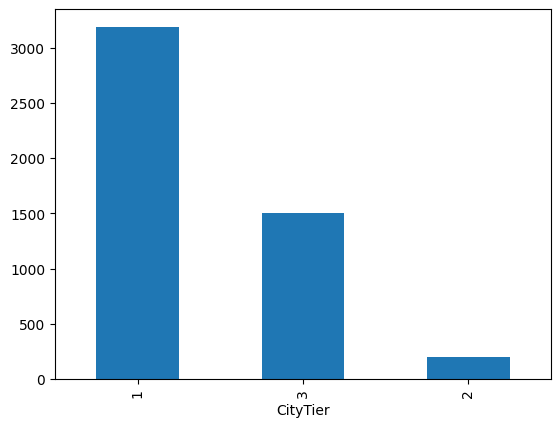

In [17]:
df['CityTier'].value_counts().plot(kind="bar")

In [18]:
df['Occupation'].value_counts()

Occupation
Salaried          2368
Small Business    2084
Large Business     434
Free Lancer          2
Name: count, dtype: int64

In [19]:
df['ProductPitched'].value_counts()

ProductPitched
Basic           1842
Deluxe          1732
Standard         742
Super Deluxe     342
King             230
Name: count, dtype: int64

In [20]:
df['MaritalStatus'].value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [21]:
#we can combine Unmarried and Single as one

df['MaritalStatus'] = df['MaritalStatus'].map({"Married": "Married", "Divorced": "Divorced", "Single": "Single", "Unmarried": "Single"})
df['MaritalStatus'].value_counts()


MaritalStatus
Married     2340
Single      1598
Divorced     950
Name: count, dtype: int64

In [22]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

#### Imputing null values as given below:

* Age: Imputing with median
* TypeofContact: Imputing with mode
* DurationOfPitch: Imputing with median
* NumberOfFollowups: Imputing with mode
* PreferredPropertyStar: Imputing with mode
* NumberOfTrips: Imputing with median
* NumberOfChildrenVisiting: Imputing with mode
* MonthlyIncome: Imputing with median


In [29]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Age'].isnull().sum()

np.int64(0)

In [30]:
df['TypeofContact'].unique()

<StringArray>
['Self Enquiry', 'Company Invited', nan]
Length: 3, dtype: str

In [45]:
df['TypeofContact'] = df['TypeofContact'].fillna(df['TypeofContact'].mode()[0])
df['TypeofContact'].isna().sum()

np.int64(0)

In [36]:
df['DurationOfPitch'] = df['DurationOfPitch'].fillna(df['DurationOfPitch'].median())
df['DurationOfPitch'].isna().sum()

np.int64(0)

In [47]:
df['NumberOfFollowups'].unique()

array([ 3.,  4.,  2.,  5., nan,  1.,  6.])

In [48]:
df['NumberOfFollowups']=df['NumberOfFollowups'].fillna(df['NumberOfFollowups'].mode()[0])
df['NumberOfFollowups'].unique()

array([3., 4., 2., 5., 1., 6.])

In [49]:
df['PreferredPropertyStar'].unique()

array([ 3.,  4.,  5., nan])

In [50]:
df['PreferredPropertyStar']=df['PreferredPropertyStar'].fillna(df['PreferredPropertyStar'].mode()[0])
df['PreferredPropertyStar'].value_counts()

PreferredPropertyStar
3.0    3019
5.0     956
4.0     913
Name: count, dtype: int64

In [51]:
df['NumberOfTrips'].unique()

array([ 1.,  2.,  7.,  5.,  6.,  3.,  4., 19., 21.,  8., nan, 20., 22.])

In [52]:
df['NumberOfTrips'] = df['NumberOfTrips'].fillna(df['NumberOfTrips'].median())
df['NumberOfTrips'].value_counts()

NumberOfTrips
2.0     1464
3.0     1219
1.0      620
4.0      478
5.0      458
6.0      322
7.0      218
8.0      105
19.0       1
21.0       1
20.0       1
22.0       1
Name: count, dtype: int64

In [ ]:
df['NumberOfChildrenVisiting'].unique()

array([ 0.,  2.,  1., nan,  3.])

In [54]:
df['NumberOfChildrenVisiting'] = df['NumberOfChildrenVisiting'].fillna(df['NumberOfChildrenVisiting'].mode()[0])
df['NumberOfChildrenVisiting'].unique()

array([0., 2., 1., 3.])

In [55]:
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['MonthlyIncome'].isna().sum()


np.int64(0)